# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [150]:
# Imports
import pandas as pd
import numpy as np
import sklearn as sk

In [151]:
# Load in the data
salary = pd.read_csv("2025_salaries.csv", header=1, encoding='latin-1')
stats = pd.read_csv("nba_2025.txt", sep=",", encoding='latin-1')


In [152]:
# Check to see where to merge on and see the shape of the salary data
print(salary.head())
print(salary.shape)

             Player   Tm    2025-26
0    Jaden Springer  NOP   $70,732 
1  Garrison Mathews  IND  $131,970 
2  Garrison Mathews  IND  $131,970 
3       Mac McClung  IND  $164,060 
4      Didi Louzada  POR  $268,032 
(471, 3)


In [153]:
# Check to see where to merge on and see the shape of the stats data
print(stats.head())
print(stats.shape)

    Rk                   Player   Age Team Pos     G    GS      MP     FG  \
0  1.0  Shai Gilgeous-Alexander  27.0  OKC  PG  49.0  49.0  1632.0  534.0   
1  2.0             Tyrese Maxey  25.0  PHI  PG  52.0  52.0  2008.0  524.0   
2  3.0         Donovan Mitchell  29.0  CLE  SG  51.0  51.0  1719.0  516.0   
3  4.0             Jaylen Brown  29.0  BOS  SF  49.0  49.0  1676.0  534.0   
4  5.0            Luka DonÄiÄ  26.0  LAL  PG  42.0  42.0  1492.0  437.0   

      FGA  ...    TRB    AST    STL   BLK    TOV     PF     PTS  Trp-Dbl  \
0   964.0  ...  218.0  314.0   64.0  38.0  103.0  101.0  1558.0      0.0   
1  1117.0  ...  214.0  351.0  102.0  40.0  126.0  118.0  1503.0      0.0   
2  1060.0  ...  229.0  302.0   79.0  15.0  159.0  125.0  1478.0      0.0   
3  1105.0  ...  336.0  229.0   49.0  20.0  176.0  136.0  1435.0      2.0   
4   923.0  ...  329.0  360.0   61.0  19.0  179.0  102.0  1379.0      6.0   

   Awards  Player-additional  
0     NaN          gilgesh01  
1     NaN         

In [154]:
# Merge the files
merged_data = pd.merge(salary, stats, on='Player')

In [155]:
#Drop variables that will not be needed or are duplicates
duplicates = merged_data[merged_data.duplicated(subset='Player', keep=False)]
print(duplicates)

                     Player   Tm    2025-26     Rk   Age Team Pos     G   GS  \
0          Garrison Mathews  IND  $131,970   398.0  29.0  IND  SG  15.0  1.0   
1          Garrison Mathews  IND  $131,970   398.0  29.0  IND  SG  15.0  1.0   
2               Mac McClung  IND  $164,060   459.0  27.0  2TM  SG   4.0  0.0   
3               Mac McClung  IND  $164,060   459.0  27.0  IND  SG   3.0  0.0   
4               Mac McClung  IND  $164,060   459.0  27.0  CHI  SG   1.0  0.0   
..                      ...  ...        ...    ...   ...  ...  ..   ...  ...   
518  Jeremiah Robinson-Earl  IND        NaN  383.0  25.0  IND  PF  17.0  3.0   
519  Jeremiah Robinson-Earl  IND        NaN  383.0  25.0  DAL  PF   5.0  0.0   
520  Jeremiah Robinson-Earl  IND        NaN  383.0  25.0  2TM  PF  22.0  3.0   
521  Jeremiah Robinson-Earl  IND        NaN  383.0  25.0  IND  PF  17.0  3.0   
522  Jeremiah Robinson-Earl  IND        NaN  383.0  25.0  DAL  PF   5.0  0.0   

        MP  ...    TRB   AST  STL  BLK 

In [156]:
# Drop the duplicate rows but keep the first entry for each player since is the most recent basketball information
merged_data = merged_data.drop_duplicates(subset='Player', keep='first')
print(merged_data)
#Confirm all duplicates are dropped
print(merged_data.duplicated(subset='Player').sum())

                     Player   Tm       2025-26     Rk   Age Team Pos     G  \
0          Garrison Mathews  IND     $131,970   398.0  29.0  IND  SG  15.0   
2               Mac McClung  IND     $164,060   459.0  27.0  2TM  SG   4.0   
5              Monte Morris  IND     $321,184   470.0  30.0  IND  PG   6.0   
6              E.J. Liddell  PHO     $706,898   461.0  25.0  BRK  PF  10.0   
7             James Wiseman  IND   $1,000,000   480.0  24.0  IND   C   4.0   
..                      ...  ...           ...    ...   ...  ...  ..   ...   
511            Bradley Beal  LAC  $59,020,270   426.0  32.0  LAC  SG   6.0   
513           Stephen Curry  GSW  $59,606,817    24.0  37.0  GSW  PG  39.0   
514          Charles Bassey  MEM           NaN  496.0  25.0  2TM   C   3.0   
517  Jeremiah Robinson-Earl  IND           NaN  383.0  25.0  2TM  PF  22.0   
523        Chris Livingston  MIL           NaN  494.0  22.0  CLE  SF   3.0   

       GS      MP  ...    TRB    AST   STL   BLK    TOV    PF  

In [157]:
# View the column names to determine which variables to keep for clustering 
print(merged_data.columns)

Index(['Player', 'Tm', '2025-26', 'Rk', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP',
       'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'Trp-Dbl', 'Awards', 'Player-additional'],
      dtype='str')


In [158]:
# See if any null values are present in the data
print(merged_data.isnull().sum())


Player                 0
Tm                     0
2025-26                3
Rk                     0
Age                    0
Team                   0
Pos                    0
G                      0
GS                     0
MP                     0
FG                     0
FGA                    0
FG%                    0
3P                     0
3PA                    0
3P%                   20
2P                     0
2PA                    0
2P%                    1
eFG%                   0
FT                     0
FTA                    0
FT%                    3
ORB                    0
DRB                    0
TRB                    0
AST                    0
STL                    0
BLK                    0
TOV                    0
PF                     0
PTS                    0
Trp-Dbl                0
Awards               414
Player-additional      0
dtype: int64


In [159]:
# View the count of the values in the columns '2025-26', '3P%', and 'Awards' with missing values to determine if they are important to keep or not

In [160]:
# View a count of the values in the column '2025-26' 
print(merged_data['2025-26'].value_counts())

2025-26
$2,296,274      32
$1,955,377      16
$2,221,677      15
$1,272,870      10
$2,349,578       5
                ..
$52,627,153      1
$54,708,609      1
$55,224,526      1
$59,020,270      1
$59,606,817      1
Name: count, Length: 285, dtype: int64


In [161]:
# Drop the rows with missing values in the 2025-26 column as it is a small number of rows and I do not think it will be important to keep for clustering
merged_data = merged_data.dropna(subset=['2025-26'])


In [162]:
# Confirm the rows with missing values are dropped
print(merged_data.isnull().sum())

Player                 0
Tm                     0
2025-26                0
Rk                     0
Age                    0
Team                   0
Pos                    0
G                      0
GS                     0
MP                     0
FG                     0
FGA                    0
FG%                    0
3P                     0
3PA                    0
3P%                   19
2P                     0
2PA                    0
2P%                    1
eFG%                   0
FT                     0
FTA                    0
FT%                    3
ORB                    0
DRB                    0
TRB                    0
AST                    0
STL                    0
BLK                    0
TOV                    0
PF                     0
PTS                    0
Trp-Dbl                0
Awards               411
Player-additional      0
dtype: int64


In [163]:
# I am going to drop this since I do not think 3P% is important becuase like post players do not shoot 3's.
# I am also going to drop '2P%' since there are other shooting variables that are better.
merged_data = merged_data.drop(columns=['3P%', '2P%'])


In [164]:
# Fill the missing award values with 0 since players with mising values likely have 0 awards.
merged_data['Awards'] = merged_data['Awards'].fillna(0)

In [165]:

# I am going to drop certain variables that I do not think have good correlation to salary or like how good you are at basketball. For example, Team, Pos, Age, GS, MP, and Player-additional.
merged_data = merged_data.drop(columns=['Rk', 'Team', 'Pos', 'Age', 'GS', 'MP', 'Player-additional', 'Tm'])
#Confirm these dropped
print(merged_data.columns)

Index(['Player', '2025-26', 'G', 'FG', 'FGA', 'FG%', '3P', '3PA', '2P', '2PA',
       'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Awards'],
      dtype='str')


In [166]:
# Keep cleaning the data 

In [167]:
# I think G, FG%, eFG%, TRB, PTS, Trp-Dbl, and Awards are the most important variables to keep for clustering 
# I think FT%, AST, STL, BLK, and PF are not that important but I still want to keep them to see if they have any correlation to salary.
# I am going to drop FG, FGA, 3P, 3PA, 2P, 2P%, FT, FTA, ORB, DRB, TOV, and PF becuase I do not think they are important for clustering and I do not want to have too many variables in my clustering. I also do not want to have any variables that are percentages as they are not as important as the other variables and they can be misleading. For example, a player could have a high FG% but if they only take a few shots then it is not as impressive as a player who takes a lot of shots and has a high FG%.
merged_data = merged_data.drop(columns=['FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB',  'DRB', 'TOV', 'PF'])
# Check that I only have left the columns I think are really important and want to see if they are important
print(merged_data.columns)

Index(['Player', '2025-26', 'G', 'FG%', 'eFG%', 'FT%', 'TRB', 'AST', 'STL',
       'BLK', 'PTS', 'Trp-Dbl', 'Awards'],
      dtype='str')


In [168]:
#Run the clustering algo with your best guess for K

In [169]:
# I am going to do K=5 becuase I hopefully I get like a cluster of the best players, a cluster of the worst players, and then 3 clusters in between. I think this will give me a good idea of how the players are clustered based on their stats and salary.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# I need to scale the data first
scaler = StandardScaler()
# First I am going to use the features PTS and TRB to see how the players are clustered becuase I think these are important features of a good player.
features = merged_data[["PTS", "TRB"]]

# Scale the features and then run the KMeans algorithm
scaled_features = scaler.fit_transform(features)
# Initialize KMeans with K=5
mymodel = KMeans(n_clusters=5, random_state=42 )
# Step 3 of sklearn,fit
mymodel.fit(scaled_features)
# Step 4 of sklearn, predict
predictions = mymodel.predict(scaled_features)
# Get the evaluation score 
mymodel.score(scaled_features)
# Make predictions for the clusters so I can visualize the clusters
merged_data['Cluster'] = predictions

In [170]:
#View the results

# this gives me the average points and total rebounds for each cluster 
print(merged_data.groupby("Cluster")[["PTS", "TRB"]].mean())


                 PTS         TRB
Cluster                         
0         684.444444  402.194444
1        1170.064516  249.967742
2         689.135135  220.067568
3         349.291971  146.832117
4         103.443609   44.015038


$1,000,000  $9,690,600 


ValueError: Unrecognized marker style 0      P
2      P
5      P
6      P
7      P
      ..
508    D
509    s
510    ^
511    P
513    s
Name: Cluster, Length: 411, dtype: str

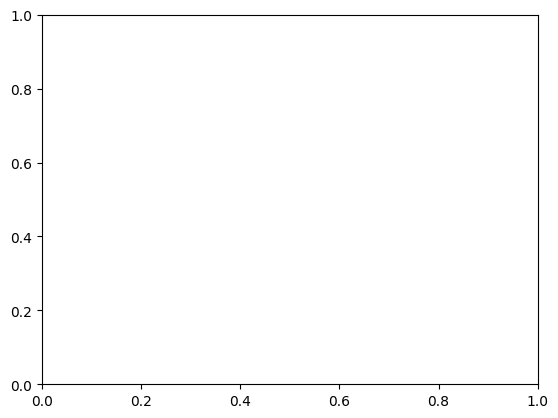

In [171]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

# THis is my initial code for the visualization, note, it will not run but i wanted to show my initial attempy at coding the visualization.
# THe corrected code will be on the next cell.

# I am going to use FG% and PTS will best differentiate the clusters.
# To visually see the clusters, I am going to make 5 shapes to represent the clusters and then color them based on salary.
# Shapes
# Note, i googled how to do this because im like very lost on why i visually cannot see the cluster groupings
markers = {0: "o", 1: "s", 2: "^", 3: "D", 4: "P"}
# Create a color map for salary with low salary being blue, medium salary being orange, and high salary being red
color_map = {'Low': 'blue', 'Medium': 'orange', 'High': 'red'}

# Now I am going to convert salary to numeric so i can have it label the points.
# View the max and min values to determine grouping 
print(merged_data['2025-26'].min(), merged_data['2025-26'].max())
# Convery it to numeric but first strip it of $ and commas and blank spaces
merged_data['2025-26'] = pd.to_numeric(
    merged_data['2025-26'].astype(str).str.replace('[$,]', '', regex=True))
#Create a new column called Salary_Grouping that used the lambda function to group salary into low, medium, and high. 
merged_data['Salary_Grouping'] = merged_data['2025-26'].apply(lambda x: 'Low' if x < 3000000 else ('Medium' if x < 6500000 else 'High'))
# SO i cannot pass Salary_Grouping as the color parameter so I need to change it 
# I am doing what the internet told me to do.
color_map = {'Low': 'blue', 'Medium': 'orange', 'High': 'red'}
plt.scatter(merged_data['FG%'], merged_data['PTS'], c=merged_data['Salary_Grouping'].map(color_map), marker=merged_data['Cluster'].map(markers))
plt.xlabel('FG%')
plt.ylabel('PTS')
plt.title('Clusters of NBA Players based on FG% and PTS')
plt.show()

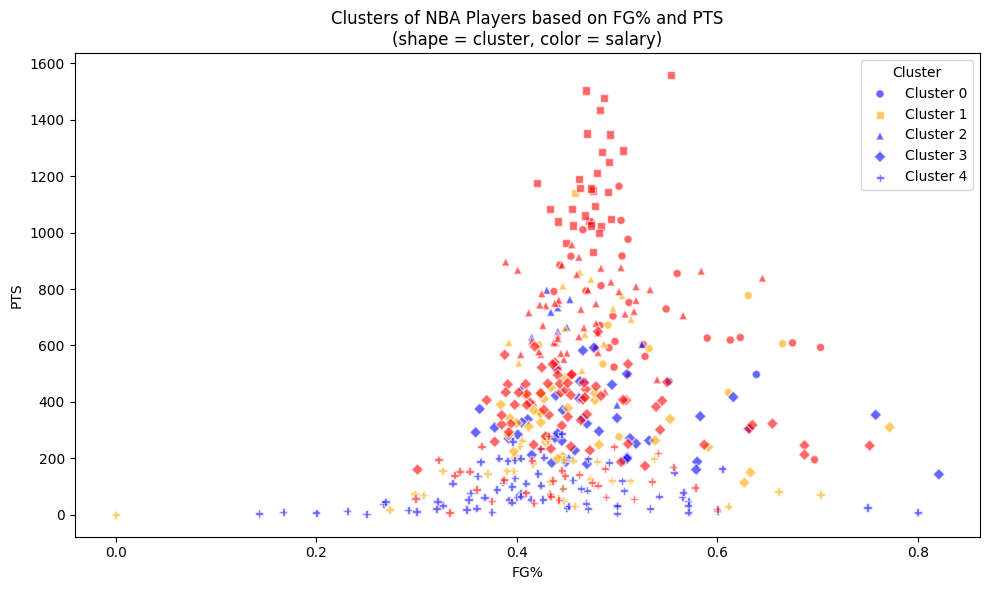

In [172]:
# THis is the correct code to visualize it.

# So first I am going to have the shape of the points represent the cluster they are apart of 
# I googled the different shapes for coding
markers = {0: "o", 1: "s", 2: "^", 3: "D", 4: "P"}
# Color salary based on low being blue, medium being orange, and high being red
color_map = {'Low': 'blue', 'Medium': 'orange', 'High': 'red'}

# Convert the numeric salary values to numeric 
merged_data['2025-26'].dtypes
merged_data['2025-26'] = merged_data['2025-26'].astype(str).str.strip().str.replace('[$,]', '', regex=True)
merged_data['2025-26'] = pd.to_numeric(merged_data['2025-26'], errors='coerce')
merged_data['Salary_Grouping'] = merged_data['2025-26'].apply(
    lambda x: 'Low' if x < 3000000 else ('Medium' if x < 6500000 else 'High')
)

plt.figure(figsize=(10, 6))
for cluster_id, grp in merged_data.groupby("Cluster"):
    plt.scatter(grp['FG%'], grp['PTS'],
                marker=markers[cluster_id],
                c=grp['Salary_Grouping'].map(color_map),
                label=f"Cluster {cluster_id}",
                alpha=0.6, edgecolors="white")

plt.xlabel('FG%')
plt.ylabel('PTS')
plt.title('Clusters of NBA Players based on FG% and PTS\n(shape = cluster, color = salary)')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [173]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
# So i googled how to calculate total variance explained and silhouette scores so this along with auto-code complete is how i am coding this
from sklearn.metrics import silhouette_score
# Calculate silhouette score
silhouette_avg = silhouette_score(scaled_features, predictions)
print("Silhouette Score: ", silhouette_avg) 
# total variance
total_variance = mymodel.inertia_
print("Total Variance Explained: ", total_variance)

# TBh i have no clue what the means so i looked it up
# Silhouette Score
# This shows how strong my clusters are. A higher score (0.5>)is good while a lower score (0.3<) is bad.

Silhouette Score:  0.4241946726067505
Total Variance Explained:  131.1855767518942


In [174]:
# Based on my silhouette score being 0.4 the quality of clustering is ok.

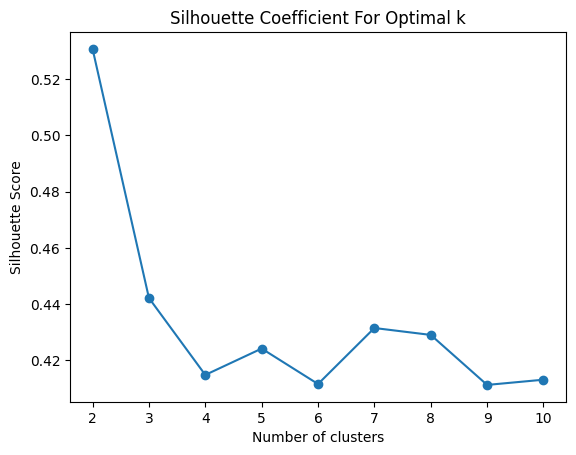

In [175]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

# SO idk how to code this by myself so i googled it and am using auto-code to do it 
# Silhouette coefficient
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_scores.append(score) 
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Coefficient For Optimal k')
plt.show()

In [176]:
# So since I used k=5 for my clustering and the silhousette score is 0.43 and mine was 0.42 the quality of my clustering is ok. 

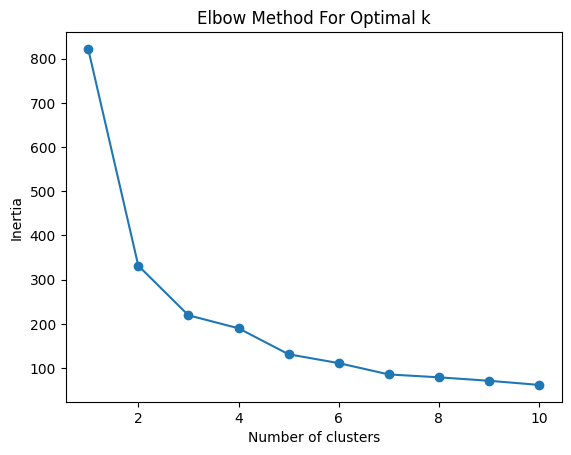

In [177]:
#Visualize the results of the elbow method

# Elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()  

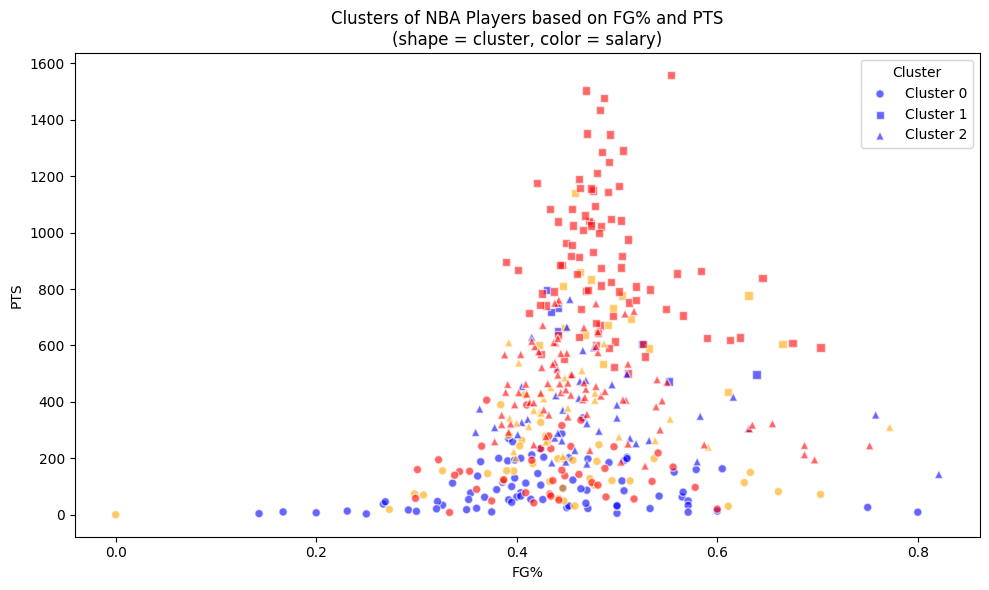

In [178]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results

# I am going to use k=3 because its the result of the elbow method which ik exactly what that means so i am going to use that.
# Use the same code as before just change k

# Use k=3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = merged_data[["PTS", "TRB"]]
scaled_features = scaler.fit_transform(features)
mymodel = KMeans(n_clusters=3, random_state=42 )
mymodel.fit(scaled_features)
predictions = mymodel.predict(scaled_features)
mymodel.score(scaled_features)
merged_data['Cluster'] = predictions



markers = {0: "o", 1: "s", 2: "^", 3: "D", 4: "P"}
color_map = {'Low': 'blue', 'Medium': 'orange', 'High': 'red'}

merged_data['2025-26'].dtypes
merged_data['2025-26'] = pd.to_numeric(merged_data['2025-26'].astype(str))
merged_data['Salary_Grouping'] = merged_data['2025-26'].apply(
    lambda x: 'Low' if x < 3000000 else ('Medium' if x < 6500000 else 'High')
)

plt.figure(figsize=(10, 6))
for cluster_id, grp in merged_data.groupby("Cluster"):
    plt.scatter(grp['FG%'], grp['PTS'],
                marker=markers[cluster_id],
                c=grp['Salary_Grouping'].map(color_map),
                label=f"Cluster {cluster_id}",
                alpha=0.6, edgecolors="white")

plt.xlabel('FG%')
plt.ylabel('PTS')
plt.title('Clusters of NBA Players based on FG% and PTS\n(shape = cluster, color = salary)')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [179]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(scaled_features, predictions)
print("Silhouette Score: ", silhouette_avg) 
total_variance = mymodel.inertia_
print("Total Variance Explained: ", total_variance)

Silhouette Score:  0.4421678329891057
Total Variance Explained:  219.46749917081658


In [180]:
#So since my silhouette score increased to 0.44 now that k=3 the quality of my clustering is slightly better than before.
# My total variance increased to 219 now that k=3 but this makes sense becuase I have less clusters so they will be farther apart.


In [146]:
#Use the model to select players for Mr. Rooney to consider

In [ ]:
#Write up the results in a separate notebook with supporting visualizations and  an overview of how and why you made the choices you did. This should be at least  500 words and should be written for a non-technical audience.